# POC 04 — three training schedules: all-months, commissioning, streaming

POC_02 v4 settled the preprocessing question: with **flow orientation** the global model
reconstructs (median window r 0.62 against 0.03), FedAvg stops costing shape (local − global
r ≈ 0.00), and other clients' local models transfer (`r_cross` 0.24–0.86). What it left
standing:

* the **drifting client** goes flat exactly in the months it drifts (A's pure `shape_amp`
  0.66 in init, 0.08 in transition, 0.06 in final);
* **bidirectional** mixed sensors stay weak;
* the weekly (weekend) modulation is missing from single-window reconstructions, so the
  prototypes cannot have it either — `ceiling` = `aligned` at r_shape 0.64;
* **every model has seen the whole horizon**, so describing month 20 uses months 21–64.

This notebook compares three schedules on the same world, selection, geometry and scaler:

| cell | schedule | what it means |
|---|---|---|
| `all` | none | the POC_02 setting: every month, every round |
| `comm` | `Schedule("commissioning", months=init)` | trained on the init months, then frozen; the rest is only encoded |
| `stream` | `Schedule("streaming", block_months=B, rounds_per_block=R)` | prequential: score the next block unseen, then train on it, carrying weights and prototypes |

Every POC_02 analysis is run on all three, and §8 asks the thesis question directly: which
schedule makes the drift most visible in the artifacts while leaving the other clients alone.

**Defaults carried over from v4:** `orient=True`, geometry `a3w84s4`, and the two objectives
that did best (`pw0` reconstruction-only, and `pw.1+s` with the spectral term, which was much
the best on the drifting client: r_pure 0.71 against 0.25).

## 0. Setup

In [1]:
import sys, pathlib, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab.worlds import load_world, pick_world
from fedwater_lab.store import Store
from fedwater_lab.specs import POC, Geometry, LossTerms, Schedule
from fedwater_lab.runner import run_cell
from fedwater_lab import data as D, recon as RC, train as T
from fedwater_lab import aligned as AL, winrec as WR, localeval as LE
from fedwater_lab import streaming as ST, compare as CP

EXPERIMENTS = REPO / "data" / "09_experiments"
pd.set_option("display.width", 220, "display.max_columns", 40)

REQUIRE_GPU = True
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
if REQUIRE_GPU:
    assert torch.cuda.is_available(), "no CUDA device visible to torch"

2.5.1+cu124 12.4 True


## 1. World, sensors, orientation

In [2]:
FILTERS = dict(sim_hash="f335b2cfad67", placement_source="dynamic") #ece8f4ad92e5
world = load_world(pick_world(EXPERIMENTS, **FILTERS))
store = Store(LAB_DIR / "lab_sandbox")
print(world.summary()[["tag", "n_months", "init_months", "final_months",
                       "drift_district", "first_switch", "last_switch"]].to_string())

GEOM = Geometry(interval_agg_h=3, window_size=84, step_size=4)
BASE = POC.with_(kinds=("flow",), classes=("pure", "mixed"), orient=True, geometry=GEOM)

OT = D.orientation_table(world, BASE)
display(OT[["client", "slot", "sensor", "tier", "purity", "sign", "frac_rev_ref",
            "bidirectional"]].round(3))
display(D.channel_alignment(world, BASE))
AUDIT = store.audit(world.sim_hash)
if len(AUDIT) and not AUDIT["ok"].all():
    display(AUDIT[~AUDIT["ok"]])
    print("set PURGE below to remove these before training")
PURGE = False
if PURGE and len(AUDIT):
    print("purged:", store.purge(world.sim_hash, AUDIT.loc[~AUDIT["ok"], "run_key"]))

tag               District_A__LR_LR_LC_LI__baseline
n_months                                         70
init_months                                   0..11
final_months                                 53..69
drift_district                           District_A
first_switch                                     12
last_switch                                      52


,client,slot,sensor,tier,purity,sign,frac_rev_ref,bidirectional
0,District_A,q_mixed_0,q_P-94,foreign,0.000,-1.0,0.459,True
1,District_A,q_mixed_1,q_P-558,foreign,0.000,-1.0,0.487,True
2,District_A,q_pure_0,q_P-42,core,1.000,-1.0,0.000,False
3,District_A,q_pure_1,q_P-44,core,1.000,-1.0,0.000,False
4,District_B,q_mixed_0,q_P-329,transition,0.732,-1.0,0.471,True
5,District_B,q_mixed_1,q_P-260,foreign,0.129,1.0,0.430,True
6,District_B,q_pure_0,q_P-30,core,1.000,1.0,0.000,False
7,District_B,q_pure_1,q_P-285,core,1.000,-1.0,0.000,False
8,District_C,q_mixed_0,q_P-509,transition,0.438,-1.0,0.000,False
9,District_C,q_mixed_1,q_P-571,foreign,0.000,1.0,0.443,True


client,District_A,District_B,District_C,District_D
channel,,,,
0,q_mixed_0 · foreign · p0.00 · +District_D · - ...,q_mixed_0 · transition · p0.73 · +District_A ·...,q_mixed_0 · transition · p0.44 · +District_B · -,q_mixed_0 · core · p1.00 · +
1,q_mixed_1 · foreign · p0.00 · +District_B · - ...,q_mixed_1 · foreign · p0.13 · +District_D · + ...,q_mixed_1 · foreign · p0.00 · +District_A · + ...,q_mixed_1 · core · p1.00 · +
2,q_pure_0 · core · p1.00 · -,q_pure_0 · core · p1.00 · +,q_pure_0 · core · p1.00 · -,q_pure_0 · core · p1.00 · +
3,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · +


## 2. The three schedules

**Equal budgets, not equal rounds.** A commissioning cell trains on the init months only and a
streaming cell on one block at a time, so the same `rounds` buys very different numbers of
optimiser steps. `ST.step_plan` reports the steps each spec will run, and
`ST.rounds_for_steps` picks rounds to hit a target. `TARGET_STEPS` is the common budget
(v4's `s4` cells ran about 2,850 steps per client).

**What carries across blocks in streaming:** the global weights, each client's local weights,
and the accumulated global prototypes (so the contrastive term of block *b* pulls towards
prototypes computed on earlier regimes — which is what makes a change show up as a pull away
from them). Adam moments restart per block, because the upstream trainer builds its
optimisers with its data.

The first block trains for `warm_rounds` so the model does not enter block 1 untrained.

In [3]:
TARGET_STEPS = 2850
INIT_LO, INIT_HI = world.phases()["init"][0], world.phases()["init"][1] - 1
BLOCK_MONTHS = 6

OBJ = {"pw0": LossTerms(proto_weight=0.0),
       "pw.1+s": LossTerms(proto_weight=0.1, spec=1.0),
       "pw1.0+s": LossTerms(proto_weight=1.0, spec=1.0)}

fw_all, _, fl_all = D.build_windows(world, BASE, cache=D.CACHE)
print({c: len(d["labels"]) for c, d in fw_all.items()}, "windows/client")

CELLS, PLAN = {}, []
for oname, lt in OBJ.items():
    base = BASE.with_(loss_terms=lt, **{"training.rounds": 30, "training.local_epochs": 5})
    cand = {
        "all": base,
        "comm": base.with_(schedule=Schedule(mode="commissioning",
                                             months=(INIT_LO, INIT_HI))),
        "stream": base.with_(schedule=Schedule(mode="streaming",
                                               block_months=BLOCK_MONTHS,
                                               rounds_per_block=5)),
    }
    # Match the step budget. `step_plan` must see the spec's OWN fl, because
    # local_epochs lives there: planning with the base fl (1 epoch) is what
    # made the first runs train 5x their target.
    flof = lambda sp: sp.as_fl(world.fl, reference_months=world.warmup_months)
    r_comm = ST.rounds_for_steps(cand["comm"], fw_all, flof(cand["comm"]), TARGET_STEPS)
    cand["comm"] = cand["comm"].with_(**{"training.rounds": r_comm})
    n_blocks = len(ST.month_blocks(range(world.n_months), BLOCK_MONTHS))
    r_str = ST.rounds_for_steps(cand["stream"], fw_all, flof(cand["stream"]),
                                TARGET_STEPS)
    cand["stream"] = cand["stream"].with_(
        schedule=Schedule(mode="streaming", block_months=BLOCK_MONTHS,
                          rounds_per_block=max(1, round(r_str / n_blocks)),
                          warm_rounds=10))
    for sname, sp in cand.items():
        key = f"{oname}·{sname}"
        CELLS[key] = sp
        PLAN.append({"cell": key, **ST.step_plan(sp, fw_all, flof(sp)),
                     "label": sp.label(), "in store": store.exists(world, sp)})

# every cell must land within ~20% of the budget, or the comparison is about
# training volume, not schedule
_p = pd.DataFrame(PLAN)
off = _p[(_p["steps"] < 0.8 * TARGET_STEPS) | (_p["steps"] > 1.2 * TARGET_STEPS)]
if len(off):
    print("OFF BUDGET (fix before reading §8):")
    display(off[["cell", "mode", "rounds", "steps"]])

display(_p.round(1))
TRAIN = list(CELLS)

{'District_A': 1250, 'District_B': 1250, 'District_C': 1250, 'District_D': 1250} windows/client


,cell,mode,windows_per_pass,batches,rounds,steps,label,in store
0,pw0·all,all,1250.0,20,30,3000,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,True
1,pw0·comm,C0-11,211.0,4,142,2840,fmp__none+or__minmax_ref__a3w84s4__u30r142e5s0...,False
2,pw0·stream,S6x24w10,104.2,2,288,2740,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False
3,pw.1+s·all,all,1250.0,20,30,3000,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,True
4,pw.1+s·comm,C0-11,211.0,4,142,2840,fmp__none+or__minmax_ref__a3w84s4__u30r142e5s0...,False
5,pw.1+s·stream,S6x24w10,104.2,2,288,2740,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False
6,pw1.0+s·all,all,1250.0,20,30,3000,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False
7,pw1.0+s·comm,C0-11,211.0,4,142,2840,fmp__none+or__minmax_ref__a3w84s4__u30r142e5s0...,False
8,pw1.0+s·stream,S6x24w10,104.2,2,288,2740,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False


In [4]:
RUNS = {}
for name in TRAIN:
    spec = CELLS[name]
    t0 = time.time()
    res = run_cell(world, spec, store=store, verbose=False)
    bad = T.fl_mismatches(spec, res["fl"])
    assert not bad, f"{name}: stored run trained with {bad}"
    RUNS[name] = res["run_key"]
    print(f"{name:<14} {res['run_key']}  cache_hit={res['cache_hit']}  "
          f"rounds={res['meta'].get('rounds')}  "
          f"train_windows={res['meta'].get('train_windows')}  {time.time() - t0:.0f}s")

pw0·all        6a52b826462d  cache_hit=True  rounds=30  train_windows=1250.0  1s
pw0·comm       468edc8613e9  cache_hit=False  rounds=142  train_windows=211.0  583s
pw0·stream     249c714615ba  cache_hit=False  rounds=274  train_windows=67.0  629s
pw.1+s·all     d355cc53223c  cache_hit=True  rounds=30  train_windows=1250.0  1s
pw.1+s·comm    ec97004a74de  cache_hit=False  rounds=142  train_windows=211.0  726s
pw.1+s·stream  bb03445c3043  cache_hit=False  rounds=274  train_windows=67.0  699s
pw1.0+s·all    2247a307cce2  cache_hit=False  rounds=30  train_windows=1250.0  879s
pw1.0+s·comm   7bfaa08fbaa5  cache_hit=False  rounds=142  train_windows=211.0  748s
pw1.0+s·stream 5f0868fa4acf  cache_hit=False  rounds=274  train_windows=67.0  694s


## 3. Sanity, per cell

The v4 columns, plus `schedule` and a `steps/client` that now counts the windows the cell
actually trained on. `sanity` asserts that each stored run's `fl` and log match its spec, and
the untrained control is the same round −1 model for all of them.

,pw0·all,pw0·comm,pw0·stream,pw.1+s·all,pw.1+s·comm,pw.1+s·stream,pw1.0+s·all,pw1.0+s·comm,pw1.0+s·stream
label,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r142e5s0...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r142e5s0...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r142e5s0...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...
run_key,6a52b826462d,468edc8613e9,249c714615ba,d355cc53223c,ec97004a74de,bb03445c3043,2247a307cce2,7bfaa08fbaa5,5f0868fa4acf
schedule,all,C0-11,S6x24w10,all,C0-11,S6x24w10,all,C0-11,S6x24w10
steps/client,3000,2840,2740,3000,2840,2740,3000,2840,2740
loss_mse_last,0.051862,0.07955,0.054626,0.053677,0.049902,0.077661,0.069504,0.057931,0.082816
d_mse_last,-0.038229,-0.083487,0.008703,-0.053554,-0.016316,0.056672,-0.042308,-0.018636,0.00591
aux_share,0.0,0.0,0.0,0.660386,0.611924,0.469742,0.913476,0.901604,0.795438
final_over_wmean,0.363664,0.814538,0.273056,0.517792,0.869557,0.315853,0.574699,0.94951,0.363567
final_over_const,0.331536,0.647243,0.232567,0.455822,0.658915,0.275743,0.519457,0.724675,0.318767
window_amp,0.79534,0.748644,0.792698,0.829474,0.974166,0.834519,0.833963,0.978287,0.821835


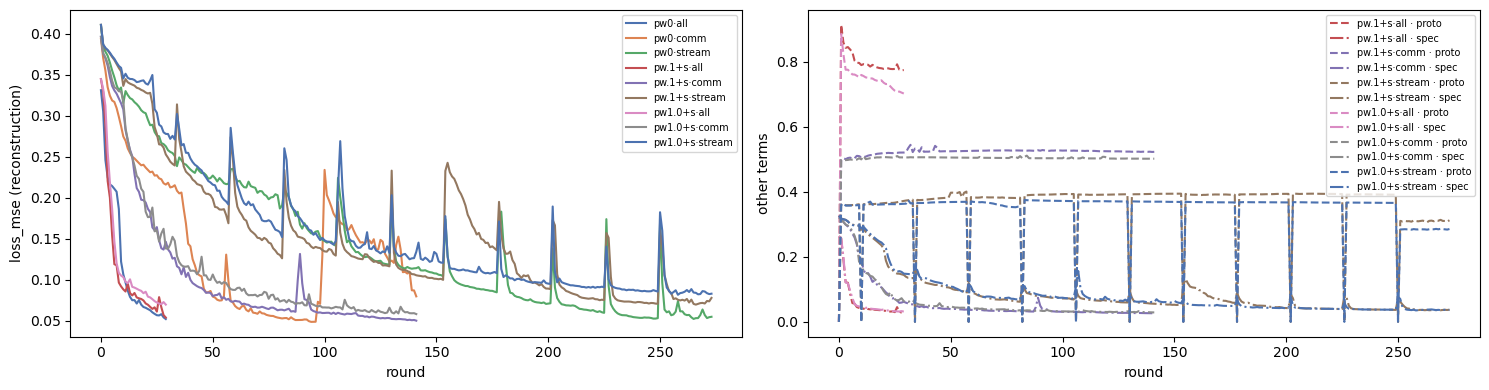

In [5]:
ALIGN24 = AL.Alignment(period_h=24, bin_h=None, block=1)
OUTS, SAN, MM = {}, {}, {}
for name in RUNS:
    OUTS[name] = AL.analyse(world, CELLS[name], ALIGN24, store=store, server=False, n_perm=99)
    SAN[name] = AL.sanity(world, OUTS[name], n_perm=99)
    ch = RC.channel_table(world, OUTS[name]["fw"])
    MM[name] = LE.model_matrix(world, OUTS[name], ch, store=store)
    SAN[name]["row"] = pd.concat([SAN[name]["row"], pd.Series(LE.lg_row(MM[name]))])
    assert OUTS[name]["checks"]["passed"].all()
    assert SAN[name]["control_check"]["passed"].all()

SANITY = pd.DataFrame({k: v["row"] for k, v in SAN.items()})
display(SANITY)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
AL.plot_losses(ax, {k: OUTS[k]["res"]["training_log"] for k in OUTS})
fig.tight_layout()
plt.show()

## 4. Focus cell, and local vs global

`FOCUS` selects the cell the detailed sections read. The gap table and the model × client
matrices are v4's: rows are models (global, then each client's local weights), columns are the
client whose windows are reconstructed.

fmp__none+or__minmax_ref__a3w84s4__u30r142e5s0__Ls1__C0-11


client,District_A,District_B,District_C,District_D
ratio_global,2.303,0.761,0.529,0.205
ratio_local,2.177,0.487,0.498,0.187
ratio_cross,2.127,1.050,0.653,0.355
amp_global,1.110,0.993,0.864,0.851
amp_local,1.147,0.965,0.884,0.907
amp_cross,1.119,1.003,0.847,0.823
r_global,0.646,0.878,0.691,0.791
r_local,0.586,0.907,0.690,0.786
r_cross,0.617,0.746,0.630,0.722
r_pure_global,0.659,0.903,0.721,0.761


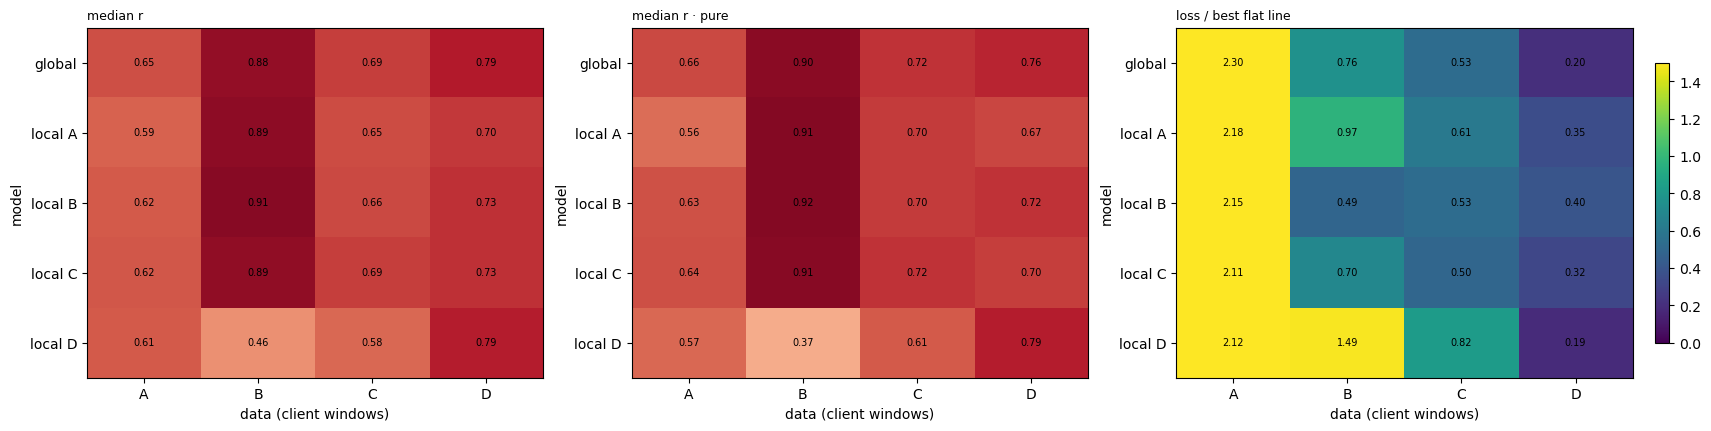

In [15]:
FOCUS = "pw1.0+s·comm" #pw1.0+s·comm
out, san = OUTS[FOCUS], SAN[FOCUS]
run, ctrl, fw, model = out["run"], san["control"], out["fw"], out["model"]
channels = RC.channel_table(world, fw)
LOCAL = LE.local_runs(world, out, store=store)
mm = MM[FOCUS]
print(CELLS[FOCUS].label())

display(LE.gap_table(mm).set_index("client").round(3).T)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), layout="constrained")
LE.plot_matrix(axes[0], mm, "r", title="median r")
LE.plot_matrix(axes[1], mm, "r_pure", title="median r · pure")
im = LE.plot_matrix(axes[2], mm, "ratio", vmin=0, vmax=1.5, cmap="viridis",
                    title="loss / best flat line")
fig.colorbar(im, ax=axes[2], shrink=0.8)
plt.show()

## 5. Window reconstruction

Per-window scores for the focus cell (global, local, untrained), then the month × start-class
grids and the position profiles. **Read the phase split:** a commissioning model is expected
to lose fidelity after the drift — that is the signal, not a failure.

pw0·all               pw0·comm               pw0·stream               pw.1+s·all               pw.1+s·comm               pw.1+s·stream               pw1.0+s·all               pw1.0+s·comm         \
                            r    amp   rmse        r    amp   rmse          r    amp   rmse          r    amp   rmse           r    amp   rmse             r    amp   rmse           r    amp   rmse            r    amp   
phase      slot_class                                                                                                                                                                                                      
final      mixed        0.677  0.624  0.399    0.567  1.035  0.466      0.721  0.766  0.292      0.601  0.769  0.419       0.692  1.202  0.449         0.701  0.830  0.343       0.621  0.792  0.406        0.653  1.182   
           pure         0.803  0.868  0.360    0.691  0.629  0.470      0.867  0.838  0.286      0.747  0.802  0.428       0.751  0.922  0.427         0.829  0.885  0.325       0.748  0.802  0.440        0.743  0.893   
init       mixed        0.853  0.612  0.387    0.792  0.767  0.375      0.782  0.643  0.422      0.733  0.729  0.427       0.925  0.913  0.260         0.770  0.701  0.419       0.738  0.727  0.450        0.921  0.939   
           pure         0.814  0.832  0.344    0.721  0.649  0.427      0.830  0.826  0.332      0.749  0.808  0.397       0.902  0.916  0.262         0.820  0.847  0.359       0.704  0.795  0.442        0.841  0.885   
transition mixed        0.694  0.620  0.398    0.615  0.872  0.442      0.690  0.726  0.334      0.632  0.750  0.425       0.685  1.009  0.433         0.682  0.778  0.379       0.655  0.775  0.419        0.672  0.995   
           pure         0.801  0.858  0.360    0.679  0.626  0.468      0.856  0.840  0.303      0.748  0.802  0.424       0.771  0.916  0.414         0.825  0.869  0.332       0.729  0.796  0.447        0.744  0.880   

                             pw1.0+s·stream                
                        rmse              r    amp   rmse  
phase      slot_class                                      
final      mixed       0.492          0.693  0.821  0.359  
           pure        0.443          0.797  0.887  0.353  
init       mixed       0.314          0.728  0.678  0.411  
           pure        0.343          0.787  0.834  0.390  
transition mixed       0.435          0.653  0.760  0.386  
           pure        0.435          0.789  0.865  0.365

global         local       
                           r    amp      r    amp
client     slot_class                            
District_A mixed       0.628  1.152  0.602  1.264
           pure        0.659  1.099  0.555  1.080
District_B mixed       0.684  1.590  0.716  1.053
           pure        0.903  0.957  0.919  0.945
District_C mixed       0.533  0.950  0.544  0.930
           pure        0.721  0.824  0.724  0.874
District_D mixed       0.797  0.877  0.785  0.912
           pure        0.761  0.837  0.787  0.904

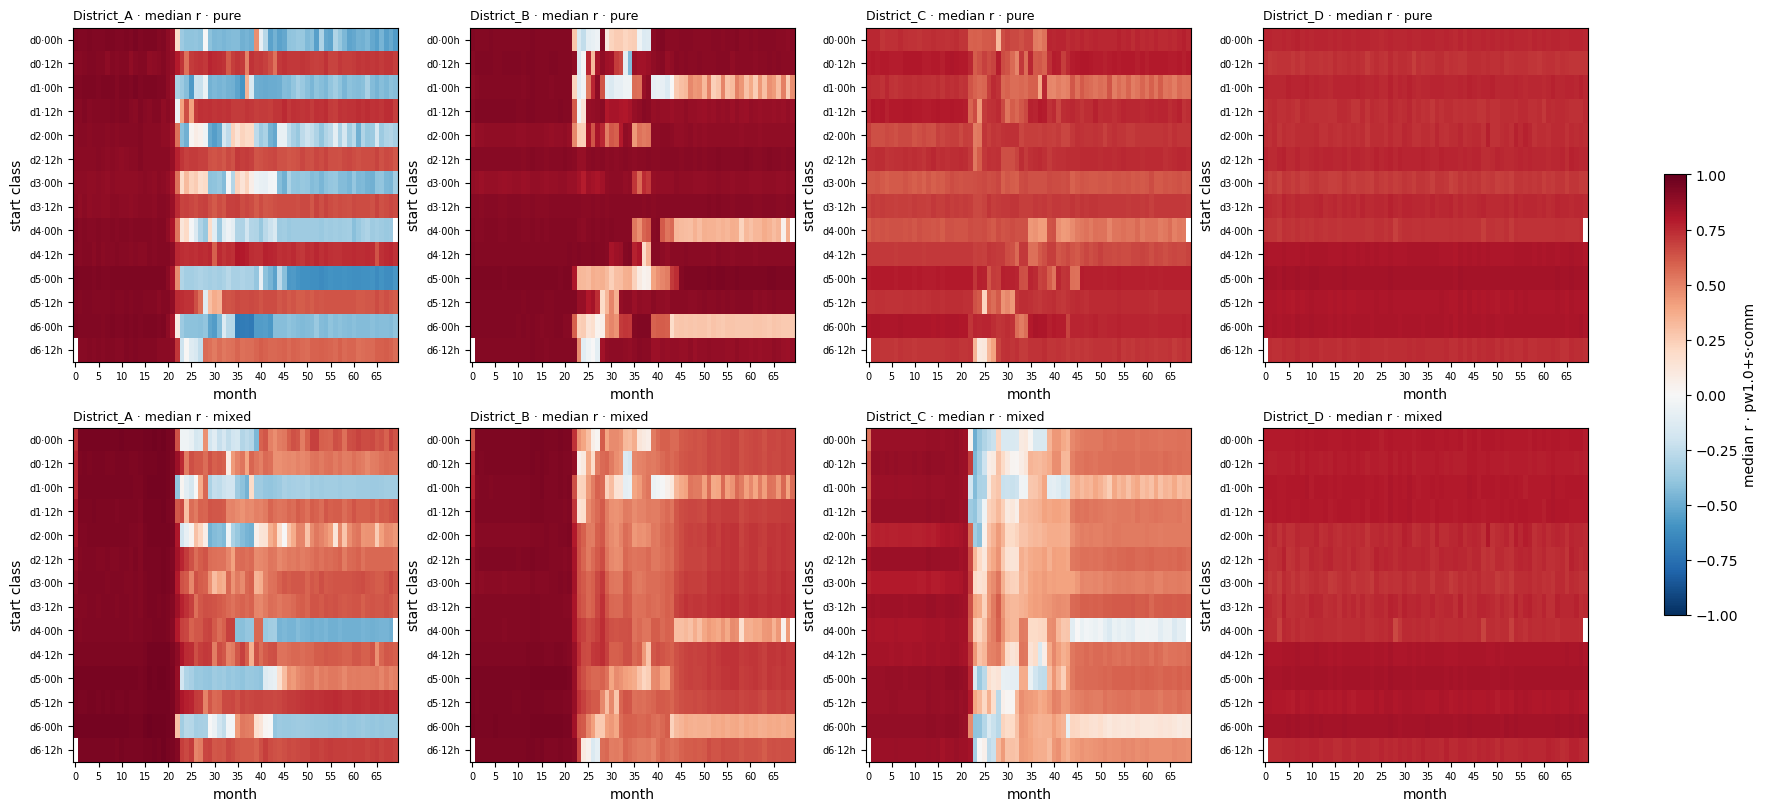

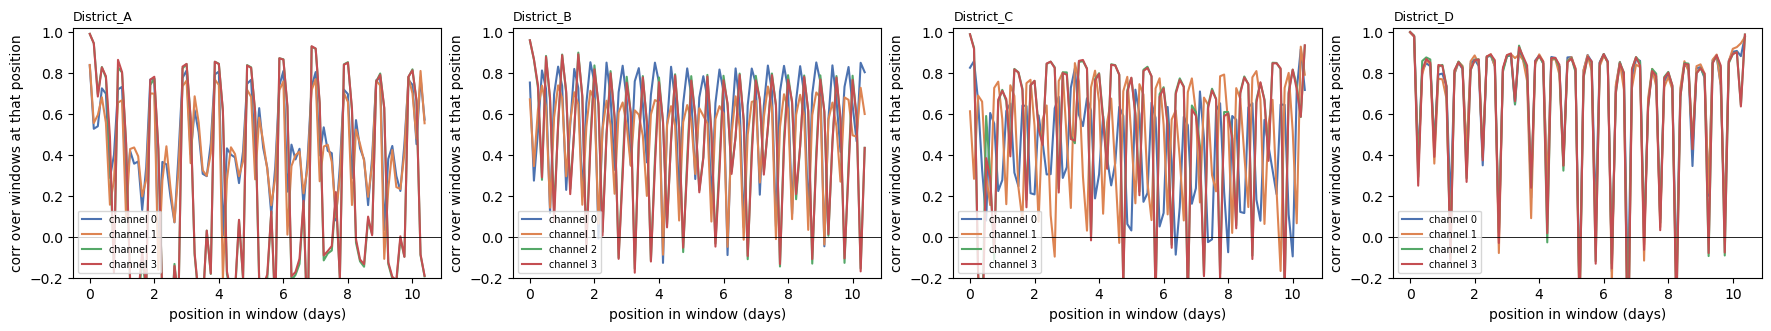

In [16]:
WS = {k: WR.window_scores(OUTS[k]["run"], OUTS[k]["fw"], channels) for k in OUTS}
display(pd.concat({k: v.groupby(["phase", "slot_class"])[["r", "amp", "rmse"]].median()
                   for k, v in WS.items()}, axis=1).round(3))

ws, ws_l = WS[FOCUS], pd.concat([WR.window_scores(LOCAL[c], {c: fw[c]}, channels)
                                 for c in LOCAL])
display(pd.concat({"global": ws.groupby(["client", "slot_class"])[["r", "amp"]].median(),
                   "local": ws_l.groupby(["client", "slot_class"])[["r", "amp"]].median()},
                  axis=1).round(3))

clients = world.client_names
fig, axes = plt.subplots(2, len(clients), figsize=(4.4 * len(clients), 8), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    for i, cls in enumerate(("pure", "mixed")):
        im = WR.plot_score_grid(axes[i, j], ws, c, "r", cls)
fig.colorbar(im, ax=axes, shrink=0.6, label=f"median r · {FOCUS}")
plt.show()

fig, axes = plt.subplots(1, len(clients), figsize=(4.4 * len(clients), 3.2), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    WR.plot_step_profile(axes[0, j], WR.step_profile(run, fw, c), run.agg_h, title=c)
plt.show()

In [ ]:
BROWSE = "District_A"
_ = WR.window_browser(LOCAL[BROWSE], {BROWSE: fw[BROWSE]},
                      ws_l[ws_l["client"] == BROWSE], channels,
                      ctrl=run, ctrl_label="global model", run_label="local model")

## 6. Weekday × hour prototypes

Same key as v4 (`P=168`, pooled per phase). v4 found the weekly modulation missing from the
prototypes *because it is missing from the single-window reconstructions* (`ceiling` equals
`aligned`). The comparison below asks whether any schedule changes that: watch `amp` and
`r_shape` against `true`, and `r2_dem` (correlation with the district's own demand).

pw0·all                       pw0·comm                       pw0·stream                       pw.1+s·all                       pw.1+s·comm                       pw.1+s·stream                 \
                            rmse r_shape    amp r2_dem     rmse r_shape    amp r2_dem       rmse r_shape    amp r2_dem       rmse r_shape    amp r2_dem        rmse r_shape    amp r2_dem          rmse r_shape    amp   
source        phase                                                                                                                                                                                                      
true          init         0.000   1.000  1.000  0.758    0.000   1.000  1.000  0.758      0.000   1.000  1.000  0.758      0.000   1.000  1.000  0.758       0.000   1.000  1.000  0.758         0.000   1.000  1.000   
              transition   0.000   1.000  1.000  0.809    0.000   1.000  1.000  0.809      0.000   1.000  1.000  0.809      0.000   1.000  1.000  0.809       0.000   1.000  1.000  0.809         0.000   1.000  1.000   
              final        0.000   1.000  1.000  0.735    0.000   1.000  1.000  0.735      0.000   1.000  1.000  0.735      0.000   1.000  1.000  0.735       0.000   1.000  1.000  0.735         0.000   1.000  1.000   
aligned       init         0.374   0.801  0.757  0.527    0.386   0.747  0.746  0.400      0.374   0.773  0.731  0.530      0.427   0.708  0.799  0.467       0.294   0.870  0.942  0.565         0.396   0.746  0.769   
              transition   0.338   0.792  0.869  0.567    0.465   0.670  0.924  0.403      0.269   0.835  0.870  0.577      0.398   0.716  0.948  0.523       0.431   0.724  1.147  0.492         0.303   0.798  0.926   
              final        0.382   0.725  0.790  0.574    0.544   0.543  0.849  0.379      0.294   0.801  0.796  0.602      0.444   0.666  0.874  0.524       0.514   0.594  1.079  0.436         0.338   0.751  0.858   
ceiling       init         0.374   0.801  0.755  0.527    0.385   0.748  0.743  0.401      0.375   0.772  0.726  0.529      0.427   0.708  0.797  0.467       0.293   0.870  0.941  0.565         0.395   0.747  0.766   
              transition   0.335   0.791  0.835  0.578    0.456   0.633  0.794  0.406      0.260   0.847  0.828  0.601      0.393   0.720  0.929  0.530       0.415   0.700  1.019  0.480         0.300   0.798  0.893   
              final        0.382   0.725  0.789  0.574    0.542   0.544  0.843  0.381      0.294   0.801  0.794  0.602      0.444   0.666  0.873  0.524       0.513   0.596  1.074  0.439         0.338   0.751  0.857   
pooled        init         0.727  -0.100  0.733  0.215    0.714  -0.057  0.750  0.214      0.670   0.073  0.702  0.241      0.697   0.030  0.740  0.083       0.686   0.133  0.908  0.123         0.698  -0.097  0.605   
              transition   0.634  -0.022  0.862  0.280    0.710  -0.042  0.953  0.314      0.627  -0.030  0.833  0.215      0.654   0.010  0.876  0.091       0.785  -0.111  1.139  0.085         0.662  -0.146  0.807   
              final        0.599   0.119  0.780  0.415    0.755  -0.044  0.889  0.339      0.628  -0.019  0.754  0.270      0.686   0.006  0.811  0.118       0.795  -0.012  1.074  0.045         0.682  -0.133  0.751   
ref_pooled    init         0.475   0.400  0.424  0.395    0.475   0.400  0.424  0.395      0.475   0.400  0.424  0.395      0.475   0.400  0.424  0.395       0.475   0.400  0.424  0.395         0.475   0.400  0.424   
              transition   0.437   0.299  0.333  0.276    0.437   0.299  0.333  0.276      0.437   0.299  0.333  0.276      0.437   0.299  0.333  0.276       0.437   0.299  0.333  0.276         0.437   0.299  0.333   
              final        0.468   0.246  0.285  0.216    0.468   0.246  0.285  0.216      0.468   0.246  0.285  0.216      0.468   0.246  0.285  0.216       0.468   0.246  0.285  0.216         0.468   0.246  0.285   
finch_aligned init         0.426   0.686  0.748  0.501    0.490   0.549  0.702  0.353      0.455   0.

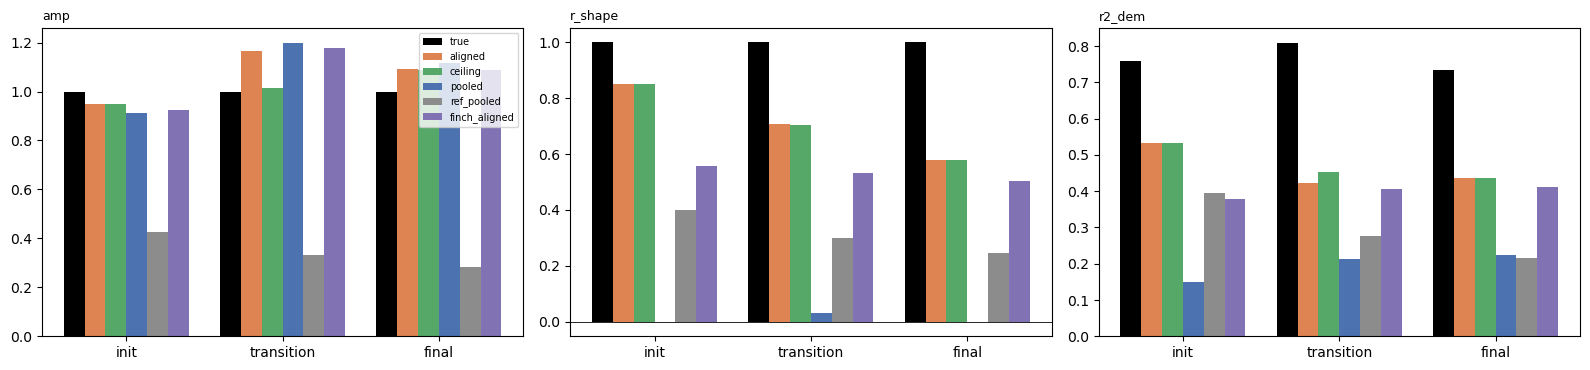

In [18]:
ALIGN168 = AL.Alignment(period_h=168, bin_h=None, block="phase")
OUT168 = {k: AL.analyse(world, CELLS[k], ALIGN168, store=store, server=True, n_perm=99)
          for k in RUNS}
display(pd.concat({k: v["summary"].set_index(["source", "phase"])[
    ["rmse", "r_shape", "amp", "r2_dem"]] for k, v in OUT168.items()}, axis=1).round(3))

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
AL.plot_ladder_summary(ax, OUT168[FOCUS]["summary"])
fig.tight_layout()
plt.show()

In [19]:
_ = AL.aligned_browser(OUT168[FOCUS]["run"], OUT168[FOCUS]["fid"], channels)

### 6b. Are the prototypes good enough for the NEXT step?

The downstream task measures dependence and similarity between clients. So score the
prototypes on exactly that, against the only yardstick available — the same quantity computed
from the raw data. Per calendar class $g$ and client pair $(c,d)$, over the selected channels:

* `s_true` $=\overline{\mathrm{corr}_t(T_{c,g,i}, T_{d,g,i})}$ — from the true class means;
* `s_dec` — the same on decoded prototypes;
* `s_lat` $=\cos(p_{c,g}, p_{d,g})$ — on the raw latent prototypes, which is what a federated
  dependence step would actually exchange.

`similarity_fidelity` reports, per phase and space: Pearson and Spearman against `s_true`, the
share of pair **orderings** preserved (`concordant` — the thing a ranking of dependencies
consumes), and the mean signed error (`s_lat` sits high because latents share a large common
direction, so its Spearman matters more than its level).

phase space  n_pairs  pearson  spearman  concordant  mean_err
cell                                                                                
pw0·all        0       final   dec       84    0.642     0.510       0.664     0.198
               1       final   lat       84   -0.365    -0.318       0.395     0.029
               2        init   dec       84    0.716     0.779       0.797     0.383
               3        init   lat       84    0.804     0.836       0.814     0.314
               4  transition   dec       84    0.598     0.655       0.739     0.195
               5  transition   lat       84   -0.299    -0.030       0.471     0.098
pw0·comm       0       final   dec       84    0.046     0.086       0.538    -0.201
               1       final   lat       84   -0.168     0.007       0.507     0.174
               2        init   dec       84    0.678     0.810       0.801     0.077
               3        init   lat       84    0.633     0.756       0.766     0.323
               4  transition   dec       84    0.083     0.149       0.556    -0.134
               5  transition   lat       84   -0.081     0.010       0.503     0.200
pw0·stream     0       final   dec       84    0.967     0.859       0.830     0.080
               1       final   lat       84    0.001    -0.054       0.479     0.053
               2        init   dec       84    0.834     0.795       0.793     0.211
               3        init   lat       84    0.746     0.666       0.732     0.349
               4  transition   dec       84    0.943     0.916       0.870     0.053
               5  transition   lat       84    0.083     0.217       0.567     0.111
pw.1+s·all     0       final   dec       84    0.524     0.495       0.674     0.157
               1       final   lat       84   -0.328    -0.288       0.402     0.219
               2        init   dec       84    0.716     0.737       0.764     0.236
               3        init   lat       84    0.702     0.692       0.747     0.415
               4  transition   dec       84    0.569     0.573       0.705     0.136
               5  transition   lat       84   -0.032     0.173       0.555     0.242
pw.1+s·comm    0       final   dec       84    0.056     0.105       0.538    -0.257
               1       final   lat       84   -0.147     0.042       0.515     0.240
               2        init   dec       84    0.977     0.889       0.855     0.050
               3        init   lat       84    0.620     0.789       0.778     0.393
               4  transition   dec       84    0.266     0.433       0.654    -0.149
               5  transition   lat       84   -0.043     0.174       0.560     0.255
pw.1+s·stream  0       final   dec       84    0.977     0.897       0.857     0.047
               1       final   lat       84   -0.076     0.062       0.515     0.170
               2        init   dec       84    0.764     0.827       0.822     0.113
               3        init   lat       84    0.712     0.861       0.832     0.375
               4  transition   dec       84    0.954     0.858       0.837     0.037
               5  transition   lat       84    0.039     0.291       0.602     0.192
pw1.0+s·all    0       final   dec       84    0.680     0.620       0.705     0.188
               1       final   lat       84   -0.177     0.029       0.507     0.001
               2        init   dec       84    0.690     0.843       0.829     0.301
               3        init   lat       84    0.483     0.598       0.704     0.341
               4  transition   dec       84    0.664     0.625       0.731     0.175
               5  transition   lat       84    0.030     0.143       0.543     0.108
pw1.0+s·comm   0       final   dec       84   -0.062     0.070       0.526    -0.225
               1       final   lat       84   -0.253    -0.178       0.438     0.277
               2        init   dec       84    0.960     0.863       0.837     0.079
               3        init

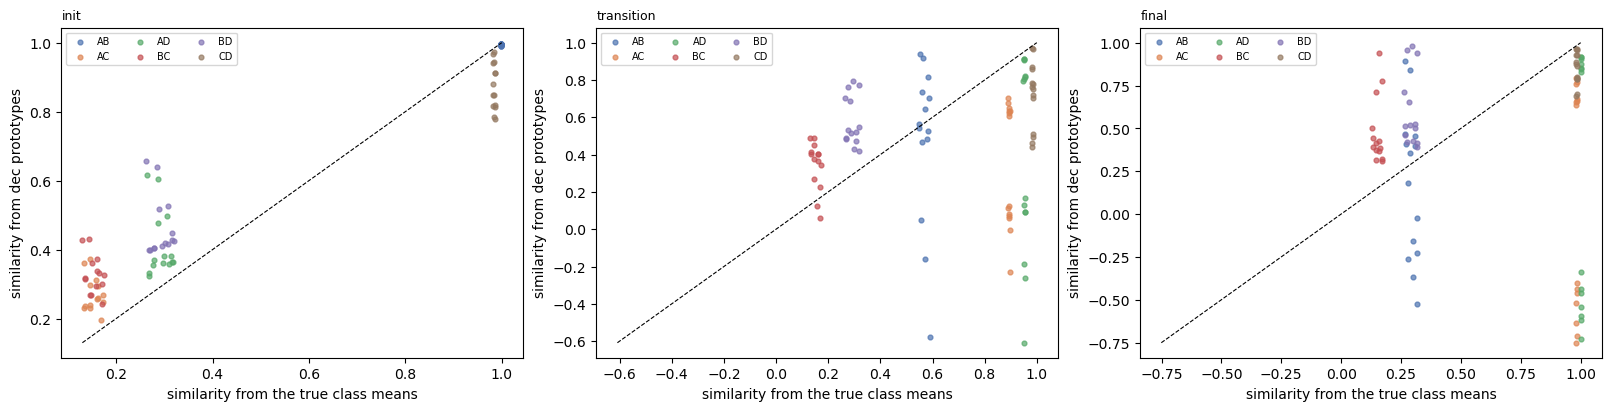

In [20]:
SIM = {k: CP.prototype_similarity(OUT168[k]["run"], channels, slot_class="pure")
       for k in RUNS}
FID = pd.concat({k: CP.similarity_fidelity(v) for k, v in SIM.items()}, names=["cell"])
display(FID.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), layout="constrained")
for ax, ph in zip(axes, RC.PERIODS):
    CP.plot_similarity(ax, SIM[FOCUS], "s_dec", ph)
plt.show()

## 7. Invariance across blocks

Per weekday·hour class, each 6-month block against the init reference (the block's own months
left out). `r_true` is the data side and is the same for every cell; `e_lat` and `r_dec` are
the representation, so they differ by schedule.

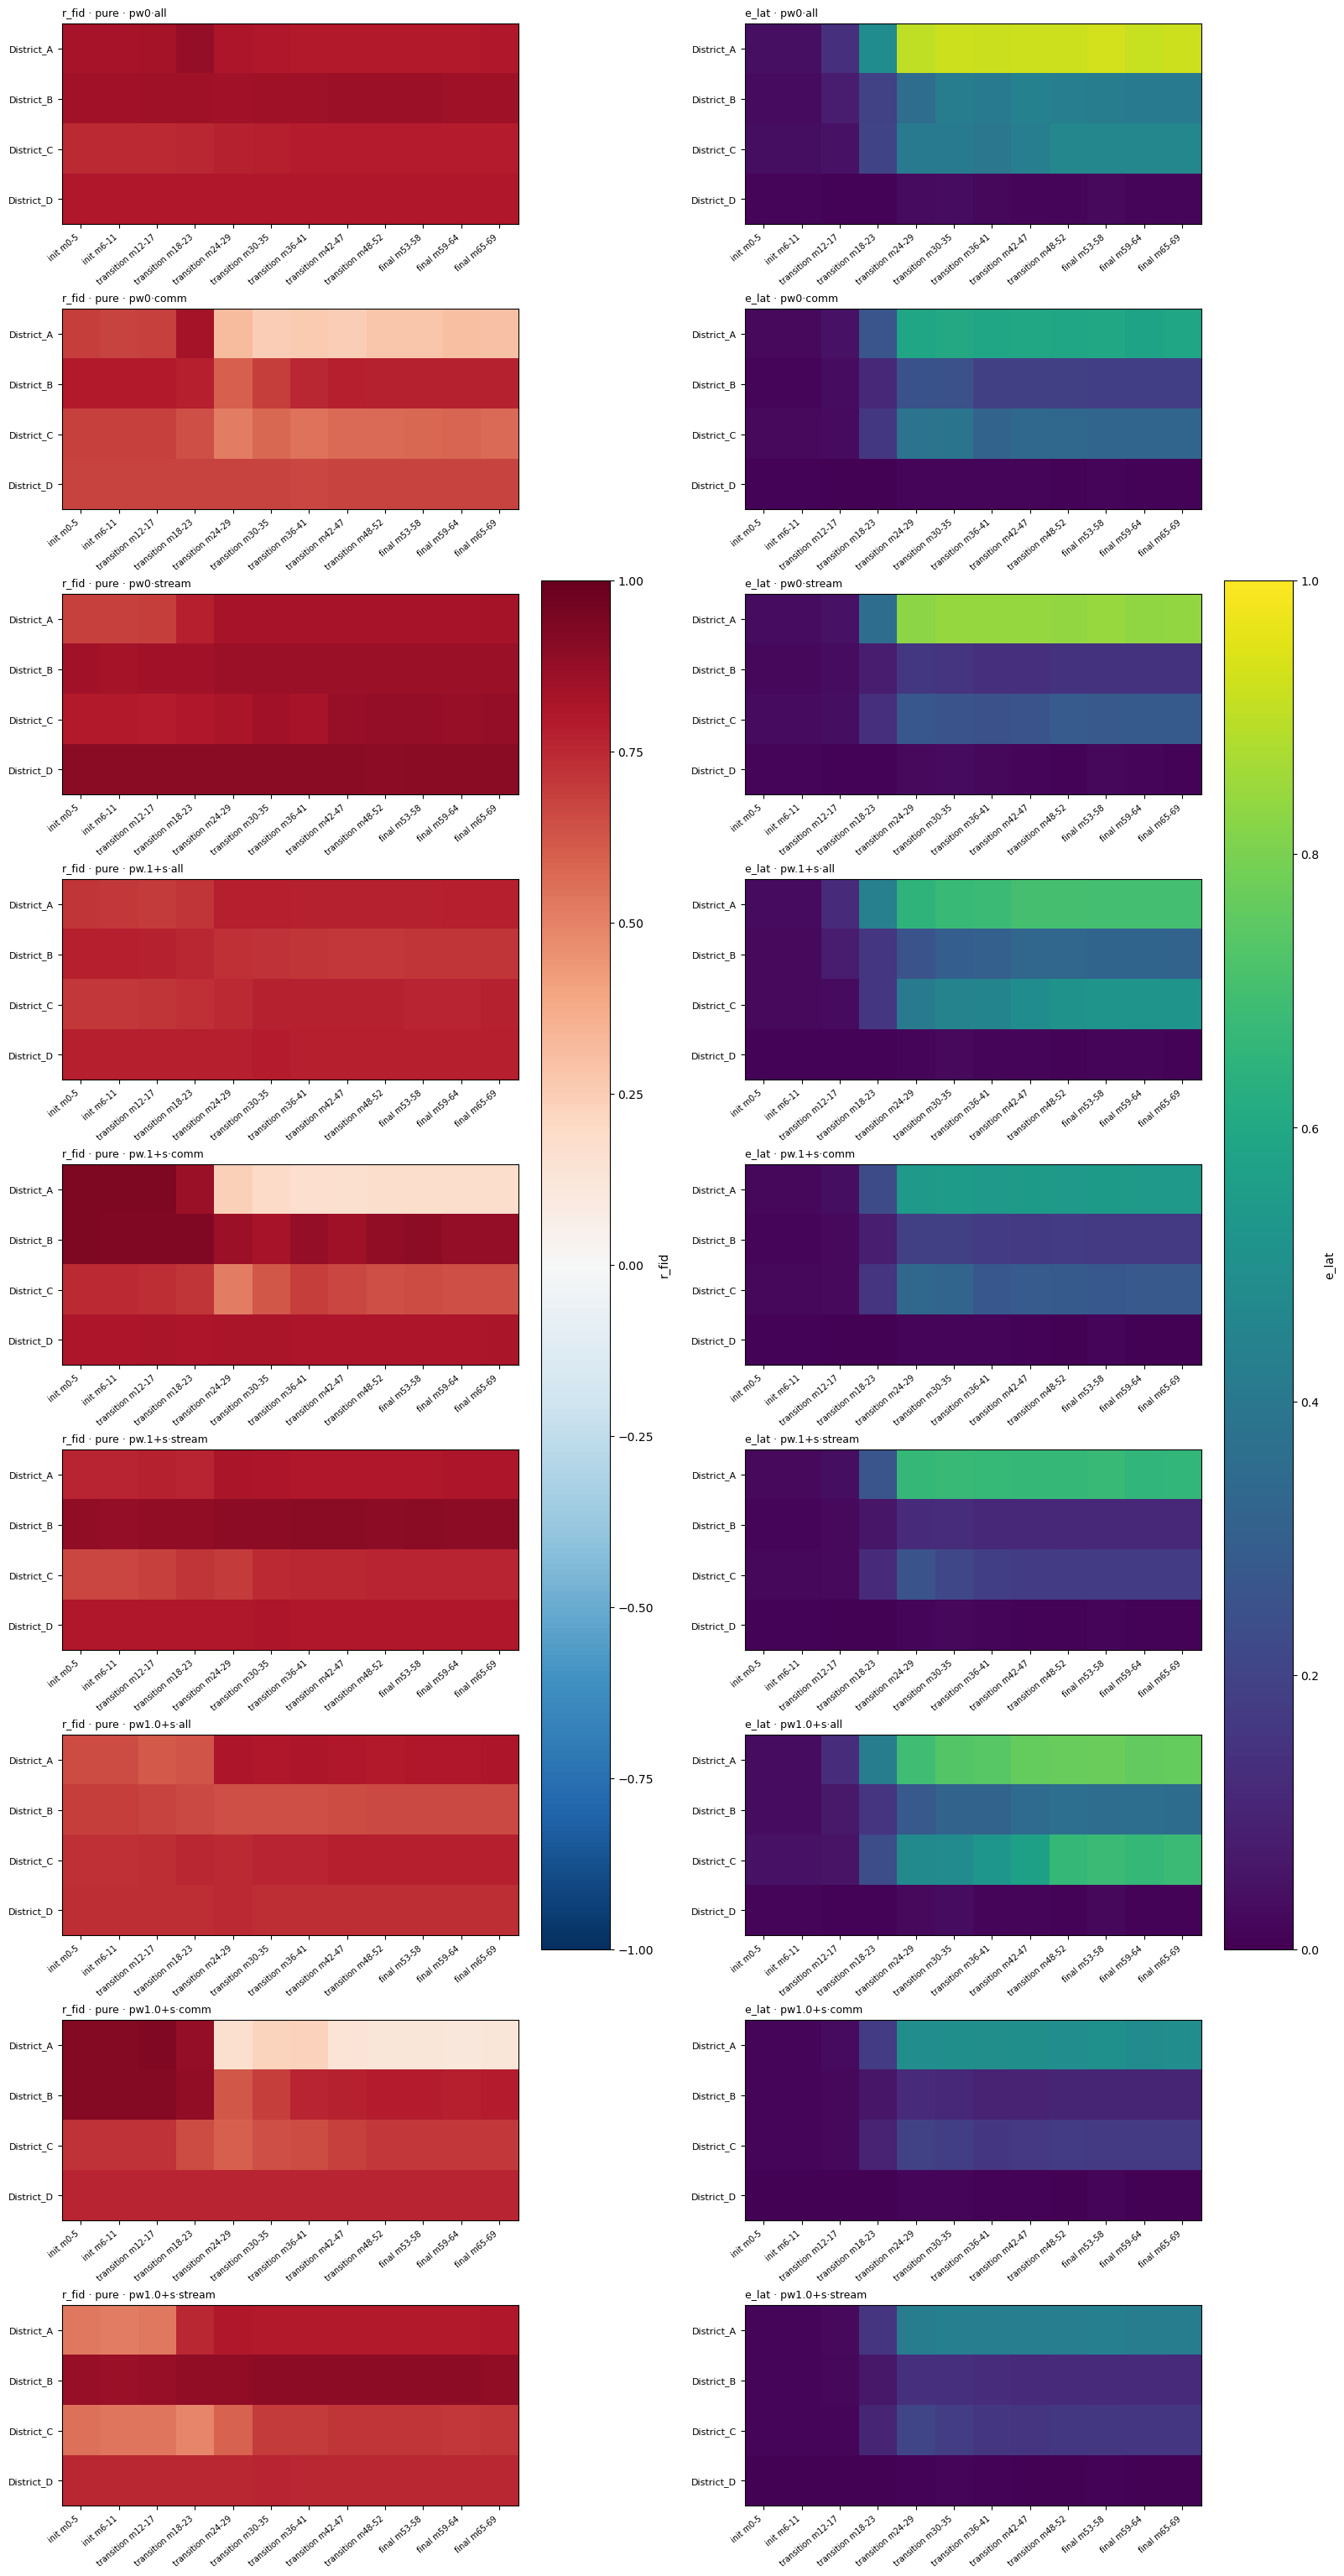

pw0·all                                                                     pw0·comm                                                                     pw0·stream         ... pw1.0+s·all  \
                        e_lat                    r_fid                   r_true                      e_lat                    r_fid                   r_true                        e_lat         ...      r_true   
phase                   final   init transition  final   init transition  final   init transition    final   init transition  final   init transition  final   init transition      final   init  ...        init   
client     slot_class                                                                                                                                                                             ...               
District_A mixed        0.924  0.042      0.745  0.684  0.881      0.788  0.693  0.998      0.754    0.588  0.026      0.468  0.291  0.787      0.424  0.693  0.998      0.754      0.839  0.034  ...       0.998   
           pure         0.924  0.042      0.745  0.796  0.823      0.813  0.294  0.998      0.481    0.588  0.026      0.468  0.290  0.684      0.409  0.294  0.998      0.481      0.839  0.034  ...       0.998   
District_B mixed        0.418  0.029      0.333  0.678  0.886      0.763  0.719  0.998      0.777    0.185  0.018      0.174  0.607  0.816      0.669  0.719  0.998      0.777      0.146  0.022  ...       0.998   
           pure         0.418  0.029      0.333  0.851  0.841      0.847  0.999  0.999      0.999    0.185  0.018      0.174  0.771  0.795      0.738  0.999  0.999      0.999      0.146  0.022  ...       0.999   
District_C mixed        0.461  0.037      0.338  0.419  0.645      0.442  0.622  0.998      0.688    0.326  0.026      0.279  0.405  0.809      0.426  0.622  0.998      0.688      0.281  0.028  ...       0.998   
           pure         0.461  0.037      0.338  0.783  0.743      0.772  0.999  0.999      0.999    0.326  0.026      0.279  0.576  0.684      0.585  0.999  0.999      0.999      0.281  0.028  ...       0.999   
District_D mixed        0.017  0.014      0.019  0.786  0.786      0.787  1.000  1.000      1.000    0.013  0.010      0.012  0.725  0.724      0.724  1.000  1.000      1.000      0.016  0.013  ...       1.000   
           pure         0.017  0.014      0.019  0.802  0.802      0.802  1.000  1.000      1.000    0.013  0.010      0.012  0.675  0.673      0.674  1.000  1.000      1.000      0.016  0.013  ...       1.000   

                                 pw1.0+s·comm                                                                     pw1.0+s·stream                                                                      
                                        e_lat                    r_fid                   r_true                            e_lat                    r_fid                   r_true                    
phase                 transition        final   init transition  final   init transition  final   init transition          final   init transition  final   init transition  final   init transition  
client     slot_class                                                                                                                                                                                 
District_A mixed           0.754        0.492  0.017      0.382  0.384  0.936      0.497  0.693  0.998      0.754          0.425  0.017      0.331  0.732  0.493      0.678  0.693  0.998      0.754  
           pure            0.481        0.492  0.017      0.382  0.117  0.921      0.383  0.294  0.998      0.481          0.425  0.017      0.331  0.796  0.519      0.751  0.294  0.998      0.481  
District_B mixed           0.777        0.102  0.013      0.087  0.638  0.925      0.698  0.719  0.998      0.777          0.121  0.013      0.104  0.670  0.682      0.685  0.719  0.998      0.777  
           pure            0.999        0.102  0.013      0.087  0.780  

In [21]:
BLOCK = 6
INV = {k: AL.invariance(world, OUTS[k]["run"].wt, OUTS[k]["fw"], OUTS[k]["model"],
                        channels, block=BLOCK) for k in RUNS}
S_T = {k: AL.invariance_summary(v) for k, v in INV.items()}
INV_C = AL.invariance(world, san["control"].wt, fw, None, channels, block=BLOCK)

fig, axes = plt.subplots(len(S_T), 2, figsize=(16, 3.4 * len(S_T)), squeeze=False,
                         layout="constrained")
for i, (k, S) in enumerate(S_T.items()):
    im = AL.plot_invariance(axes[i, 0], S, "r_fid", "pure", vmin=-1, vmax=1)
    axes[i, 0].set_title(f"r_fid · pure · {k}", fontsize=9, loc="left")
    im2 = AL.plot_invariance(axes[i, 1], S, "e_lat", "pure", vmin=0, vmax=1, cmap="viridis")
    axes[i, 1].set_title(f"e_lat · {k}", fontsize=9, loc="left")
fig.colorbar(im, ax=axes[:, 0], shrink=0.6, label="r_fid")
fig.colorbar(im2, ax=axes[:, 1], shrink=0.6, label="e_lat")
plt.show()

display(pd.concat({k: v.pivot_table(index=["client", "slot_class"], columns="phase",
                                    values=["r_true", "r_fid", "e_lat"])
                   for k, v in S_T.items()}, axis=1).round(3))

## 8. Drift visibility — the comparison

Per (client, month), two signals from each cell:

* **reconstruction**: median `r` and `rmse` over that month's windows;
* **latent displacement**: `e_lat` $=\lVert z_m - z_{ref}\rVert / \lVert z_{ref}\rVert$ and
  `cos_lat`, against the client's own init mean latent.

`visibility` reduces each to one number,

$$z = \frac{\mathrm{median}_{post} - \mathrm{median}_{ref}}{\mathrm{IQR}_{ref}}$$

with `post` from `first_switch` on, and `r` negated so that positive always means "moved".
`contrast` is the drifting client's $z$ minus the largest of the others: **a schedule is good
for drift detection when contrast is large**, i.e. it moves for A and not for B, C, D.

For the streaming cell there is a stronger signal still: each block is scored **before** it is
trained on, so `prequential` is an out-of-sample curve over time, and the honest latents of
that moment are in `latent_trajectories_preq`.

--- z per client, signal = e_lat


,pw0·all,pw0·comm,pw0·stream,pw.1+s·all,pw.1+s·comm,pw.1+s·stream,pw1.0+s·all,pw1.0+s·comm,pw1.0+s·stream
client,,,,,,,,,
District_A,73.06,119.30,76.32,118.00,75.51,90.97,69.55,82.09,90.03
District_B,95.11,30.25,35.81,99.47,37.66,32.33,171.44,25.45,45.48
District_C,41.30,59.75,25.42,201.74,26.28,27.25,99.71,37.88,34.72
District_D,-0.09,-0.37,-0.38,0.09,-0.39,-0.24,-0.29,-0.25,-0.48
contrast,-22.04,59.55,40.52,-83.74,37.85,58.65,-101.89,44.21,44.55


--- z per client, signal = r


,pw0·all,pw0·comm,pw0·stream,pw.1+s·all,pw.1+s·comm,pw.1+s·stream,pw1.0+s·all,pw1.0+s·comm,pw1.0+s·stream
client,,,,,,,,,
District_A,5.92,13.43,-10.17,-3.22,175.55,-3.75,-14.22,149.00,-6.58
District_B,-5.86,5.11,-6.39,15.77,5.25,-2.92,6.07,15.46,-4.75
District_C,-11.61,5.65,-1.62,-11.83,3.80,-5.73,-5.62,-0.63,-13.07
District_D,0.10,0.09,-0.01,-0.04,-0.34,-0.15,0.33,-0.37,-0.35
contrast,5.81,7.78,-10.17,-18.99,170.29,-3.60,-20.29,133.54,-6.22


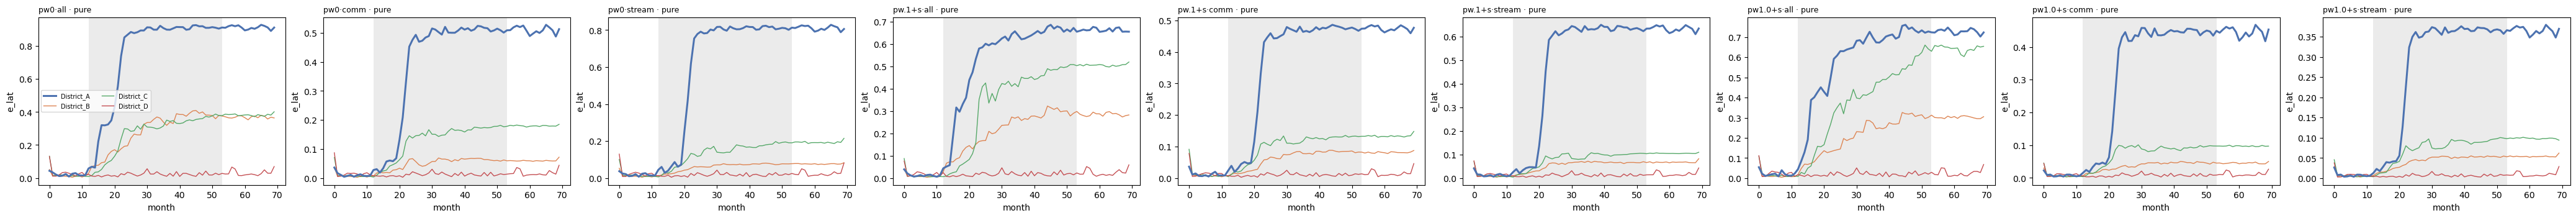

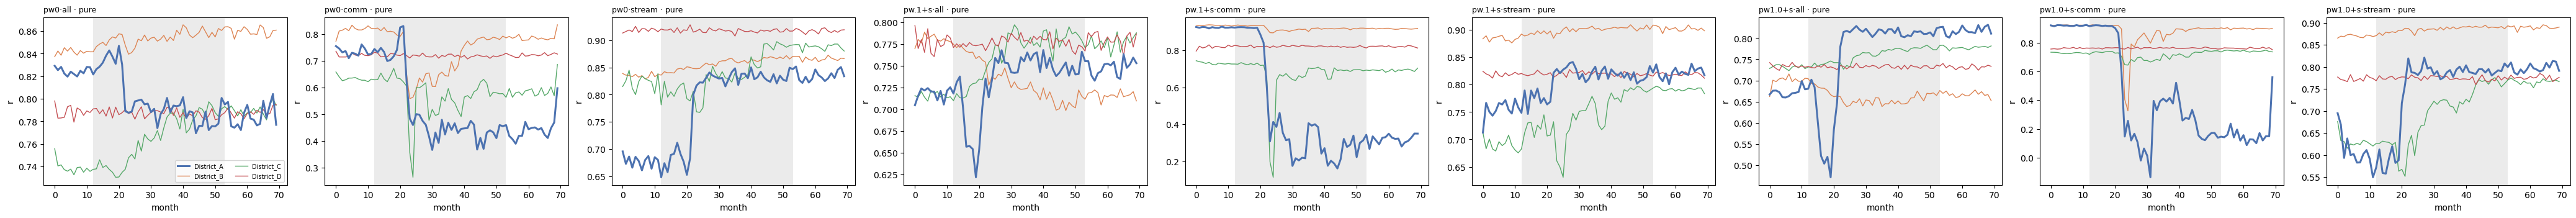

In [22]:
PROF = {k: CP.drift_profile(world, OUTS[k]["run"], OUTS[k]["fw"], channels,
                            slot_class="pure") for k in RUNS}
VIS = {k: CP.visibility(PROF[k], world) for k in PROF}

for sig in ("e_lat", "r"):
    print(f"--- z per client, signal = {sig}")
    display(CP.compare_visibility(VIS, world, sig).round(2))

for sig in ("e_lat", "r"):
    fig, axes = plt.subplots(1, len(PROF), figsize=(4.6 * len(PROF), 3.4), squeeze=False,
                             layout="constrained")
    CP.plot_profiles(axes[0], PROF, world, sig, slot_note=" · pure")
    plt.show()

r         ratio       
model           global  local global  local
block m_lo m_hi                            
0     0    5    -0.017 -0.017  1.216  1.216
1     6    11   -0.006  0.019  0.952  0.859
2     12   17    0.076  0.067  0.753  0.663
3     18   23    0.111  0.121  0.760  0.729
4     24   29    0.275  0.340  0.698  0.600
5     30   35    0.485  0.518  0.563  0.454
6     36   41    0.595  0.603  0.448  0.385
7     42   47    0.609  0.646  0.407  0.334
8     48   53    0.657  0.706  0.337  0.269
9     54   59    0.734  0.776  0.286  0.224
10    60   65    0.764  0.795  0.237  0.194
11    66   69    0.788  0.810  0.203  0.177

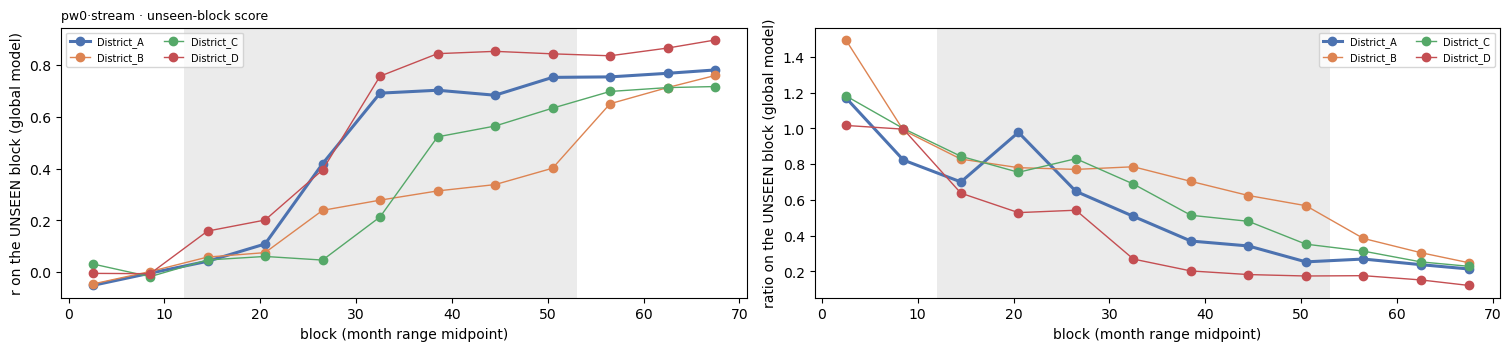

r         ratio       
model           global  local global  local
block m_lo m_hi                            
0     0    5    -0.017 -0.017  1.216  1.216
1     6    11    0.003  0.014  0.994  0.912
2     12   17    0.283  0.337  0.737  0.600
3     18   23    0.545  0.666  0.750  0.608
4     24   29    0.551  0.632  0.785  0.574
5     30   35    0.618  0.689  0.582  0.431
6     36   41    0.660  0.707  0.448  0.337
7     42   47    0.692  0.723  0.372  0.300
8     48   53    0.506  0.570  0.494  0.409
9     54   59    0.700  0.733  0.321  0.282
10    60   65    0.739  0.769  0.277  0.230
11    66   69    0.751  0.773  0.258  0.228

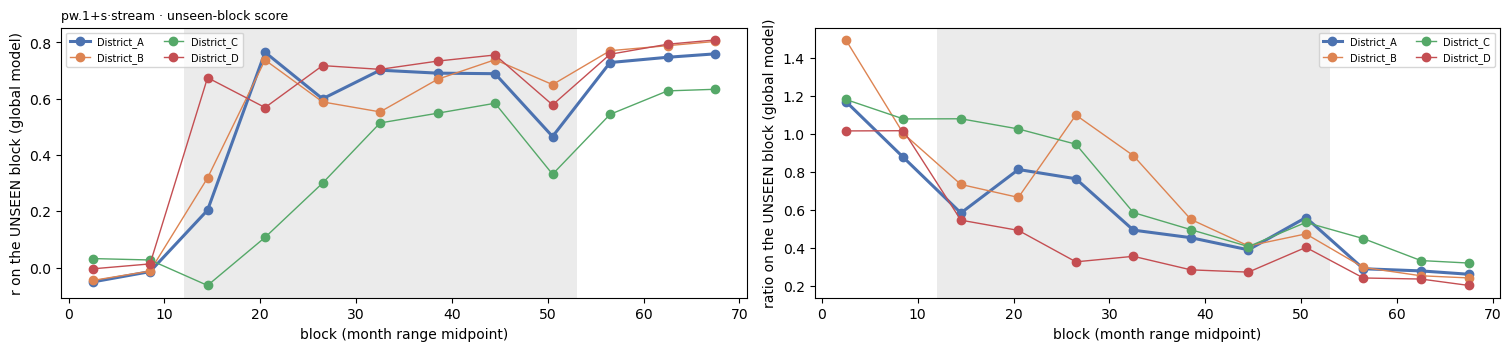

r         ratio       
model           global  local global  local
block m_lo m_hi                            
0     0    5    -0.017 -0.017  1.216  1.216
1     6    11   -0.012 -0.006  1.007  0.940
2     12   17    0.204  0.304  0.825  0.647
3     18   23    0.537  0.627  0.820  0.705
4     24   29    0.507  0.584  0.891  0.655
5     30   35    0.608  0.672  0.666  0.464
6     36   41    0.629  0.689  0.542  0.369
7     42   47    0.634  0.695  0.494  0.348
8     48   53    0.675  0.716  0.439  0.314
9     54   59    0.694  0.730  0.396  0.292
10    60   65    0.704  0.733  0.367  0.284
11    66   69    0.728  0.738  0.334  0.270

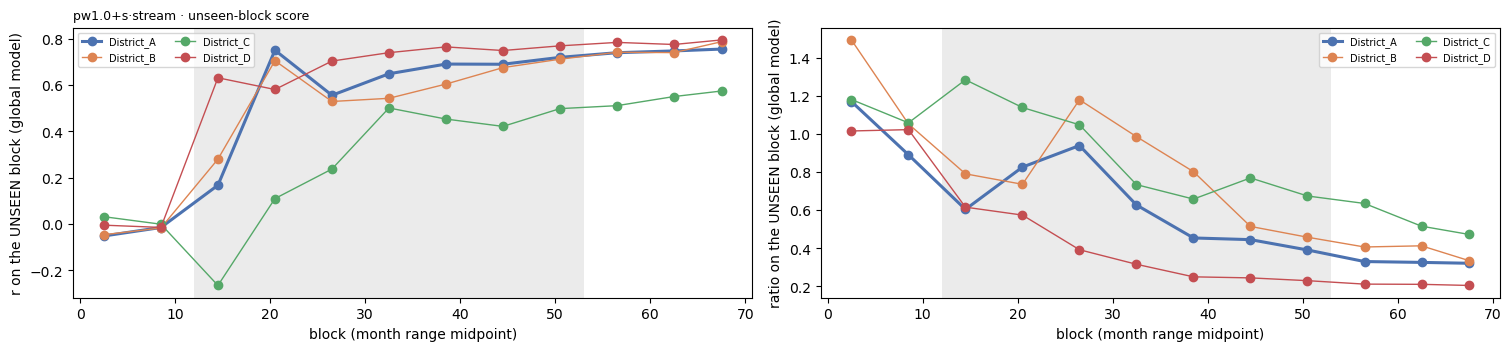

In [23]:
STREAM_CELLS = [k for k in RUNS if OUTS[k]["res"].get("prequential") is not None]
for k in STREAM_CELLS:
    preq = OUTS[k]["res"]["prequential"]
    display(preq.pivot_table(index=["block", "m_lo", "m_hi"], columns="model",
                             values=["r", "ratio"]).round(3))
    fig, ax = plt.subplots(1, 2, figsize=(15, 3.4), layout="constrained")
    CP.plot_prequential(ax[0], preq, world, "r")
    CP.plot_prequential(ax[1], preq, world, "ratio")
    ax[0].set_title(f"{k} · unseen-block score", fontsize=9, loc="left")
    plt.show()

## What to read out of this

* **Which schedule wins on `contrast`?** That is the thesis-relevant number: drift visible in
  the drifting client, quiet elsewhere. The all-months model can absorb the drift (it trains
  on it), so the expectation is `comm` ≥ `stream` > `all` on reconstruction-based signals, and
  a smaller difference on latent displacement.
* **Fidelity is the counterweight.** A commissioning model should be the best on init months
  and the worst afterwards. If it is also worse on init (fewer windows, so fewer steps despite
  the matched budget), the comparison is about data volume, not the schedule.
* **Prequential is the only out-of-sample number here.** Everything else, in every cell, is
  in-sample.

**Open after this:**
* the weekend modulation is a fidelity gap, not an averaging one; the levers are a smaller
  stride, the spectral term, or explicit calendar conditioning of the decoder (upstream);
* bidirectional sensors need their own encoding (magnitude plus direction);
* `final` is one month in this world, so the post-drift side rests on the transition blocks;
* a world with distinct sector maps is still what the regime-recovery question needs.